In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from imblearn.over_sampling import SMOTE


In [ ]:
# Load dataset
df = pd.read_csv("UNSW_NB15_training-set.csv")

# Separate features and target
X = df.drop(columns=["label", "attack_cat"])
y = df["attack_cat"]

# Separate features and target
X = df.drop(columns=["label", "attack_cat"])
y = df["attack_cat"]

# Derived features
X["byte_ratio"] = X["sbytes"] / (X["dbytes"] + 1)
X["pkt_size_ratio"] = X["smean"] / (X["dmean"] + 1)
X["traffic_rate"] = X["sload"] / (X["dload"] + 1)
X["ttl_diff"] = X["sttl"] - X["dttl"]
X["srv_dst_ratio"] = X["ct_srv_dst"] / (X["ct_dst_src_ltm"] + 1)

# Load existing label encoder + preprocessor
label_encoder = joblib.load("label_encoder_full.pkl")
preprocessor = joblib.load("preprocessor_full.pkl")

# Encode target labels
y_encoded = label_encoder.transform(y)


In [3]:
# Split into train, val, test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Preprocess with existing preprocessor
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Convert sparse to dense for SMOTE
X_train_proc = X_train_proc.toarray()


In [4]:
# Apply SMOTE (lighter strategy)
smote = SMOTE(random_state=42, sampling_strategy="not majority")
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Before SMOTE:\n", pd.Series(y_train).value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_res).value_counts())


Before SMOTE:
 6    39200
5    28000
3    23375
4    12729
2     8585
7     7343
0     1400
1     1222
8      793
9       91
Name: count, dtype: int64

After SMOTE:
 5    39200
3    39200
6    39200
4    39200
2    39200
7    39200
0    39200
1    39200
8    39200
9    39200
Name: count, dtype: int64


In [5]:
# RandomForest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# Train
rf_model.fit(X_train_res, y_train_res)

# Save model
joblib.dump(rf_model, "random_forest_multi_smote.pkl", compress=3)
print("RandomForest trained with SMOTE and saved successfully!")


RandomForest trained with SMOTE and saved successfully!



Test Accuracy: 0.8429016804805718
Test Macro F1: 0.6296733476203455

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.23      0.21      0.22       300
      Backdoor       0.21      0.19      0.20       262
           DoS       0.35      0.40      0.37      1840
      Exploits       0.75      0.73      0.74      5009
       Fuzzers       0.80      0.87      0.83      2728
       Generic       1.00      0.98      0.99      6000
        Normal       0.99      0.95      0.97      8400
Reconnaissance       0.77      0.78      0.78      1574
     Shellcode       0.58      0.91      0.71       170
         Worms       0.42      0.58      0.49        19

      accuracy                           0.84     26302
     macro avg       0.61      0.66      0.63     26302
  weighted avg       0.85      0.84      0.85     26302



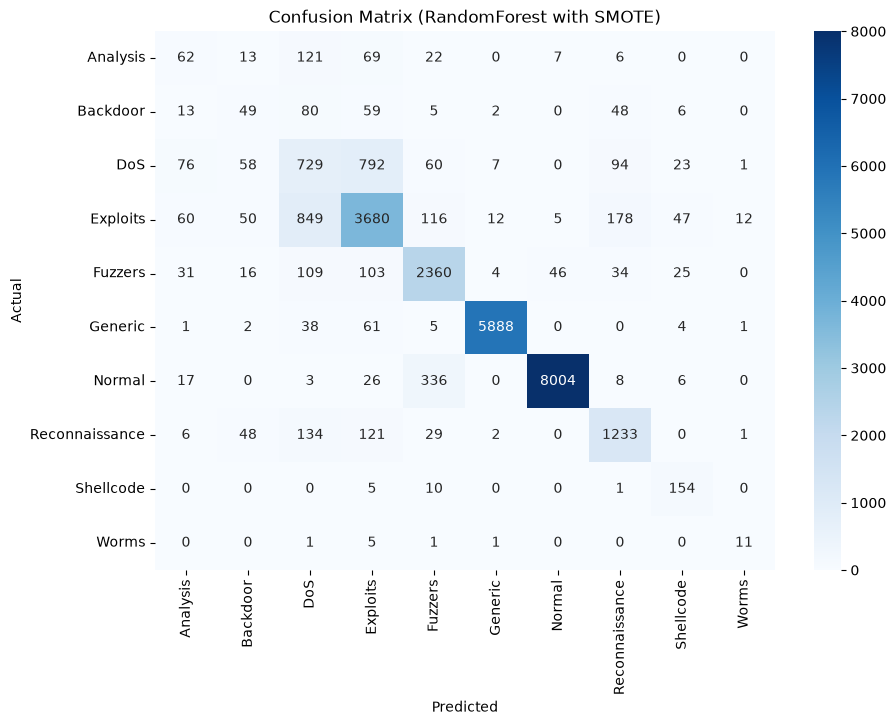

In [ ]:
# Predict on processed test set
y_pred_encoded = rf_model.predict(X_test_proc)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Convert y_test back to original labels for comparison
y_test_labels = label_encoder.inverse_transform(y_test)

print("\nTest Accuracy:", accuracy_score(y_test_labels, y_pred))
print("Test Macro F1:", f1_score(y_test_labels, y_pred, average="macro", zero_division=0))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (RandomForest with SMOTE)")
plt.show()
